# Building an Artificial Neural Network (ANN) from Scratch



Welcome to this comprehensive course on building Artificial Neural Networks from scratch! This notebook contains both theoretical concepts and practical implementations.

## Prerequisites
- Basic Python programming
- Understanding of basic calculus and linear algebra
- Familiar with NumPy

## Course Outline

1. Introduction to Neural Networks
2. Implement Neural Network
3. Neural Network Regression
4. Neural Network Classification

Let's begin our journey into the fascinating world of Neural Networks!


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# 1. Introduction to Neural Networks

## What is a Neural Network?

An Artificial Neural Network (ANN) is a computational model inspired by the way biological neural networks in the human brain work. The basic building block of every artificial neural network is the **neuron**, also known as a node or unit.

Key components of a neural network:
1. **Input Layer**: Receives the raw input data
2. **Weights and Biases**: Parameters that are learned during training
3. **Activation Functions**: Non-linear functions that help the network learn complex patterns
4. **Hidden Layers**: Processes the data through weighted connections
5. **Output Layer**: Produces the final output

Let's start with input layer.  


## 1.1 Input Layer

The input layer is the first layer of a neural network and serves as the entry point for our data. It receives the raw input features and passes them to the subsequent layers for processing.

 ### Example Input Data:
 - **Regression**: Housing prices with features like area, bedrooms, location
 - **Classification**: Images, text, or tabular data with multiple features
 
 Let's look at some examples of input data preparation:


In [3]:
# Regression Example - Housing Dataset
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
#housing = fetch_california_housing()
#X, y = housing.data, housing.target
#print(X.shape, y.shape)

# Load the dataset from Excel
df = pd.read_excel("/Teach/129_AI/Week10-11/fetch_california_housing.xlsx")

# Rename target column to match common naming
df = df.rename(columns={'target': 'Price'})

X = df.drop(columns=['Price'])
y = df['Price']

# Basic statistics（
print("Dataset Shape:", df.shape)
print("\nFeature Statistics:")
print(df.describe())

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Dataset Shape: (20640, 9)

Feature Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532  

(1000, 2) (1000,)


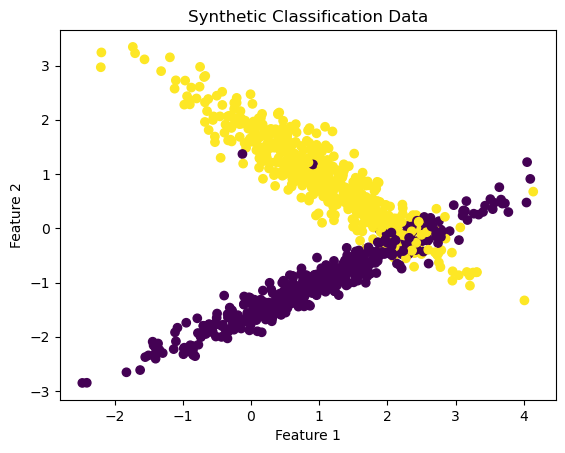

In [4]:
# Classification Example (Binary)
from sklearn.datasets import make_classification


X_binary, result = make_classification(n_samples=1000, n_features=2, n_redundant=0, 
                         n_informative=2, random_state=42, 
                         n_clusters_per_class=1)
print(X_binary.shape, result.shape)
X_binary_scaled = StandardScaler().fit_transform(X_binary)

# Visualize the dataset
plt.scatter(X_binary[:, 0], X_binary[:, 1], c=result, cmap='viridis')
plt.title('Synthetic Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 1.2 Weights and Biases
 In an artificial neural network, each connection between neurons is associated with a weight, and each neuron (except those in the input layer) has an additional parameter called a bias. 
 
 - **Weights** determine the strength and direction of the connection between two neurons. During training, the network learns by adjusting these weights to minimize the error between its predictions and the actual targets.
 - **Biases** allow the activation function to be shifted to the left or right, which helps the model fit the data better by providing additional flexibility.

 Together, weights and biases are the key parameters that the learning algorithm updates during training. 
 
 Proper initialization and understanding of these parameters are crucial for building effective neural networks.


In [5]:
class NeuralNetworkLayer:
    def __init__(self, input_size, output_size):
        # Initialize weights using He initialization
        self.weights = np.random.randn(output_size, input_size) * np.sqrt(2/input_size)
        
        # Initialize biases to small values
        self.biases = np.zeros((output_size, 1))
        
    def forward(self, input_data):
        """Forward pass computation"""
        self.input = input_data
        # Compute weighted sum plus bias
        self.z = np.dot(self.weights, self.input) + self.biases
        # Apply activation function
        self.output = self.activation(self.z)
        return self.output




## 1.3 Activation Functions

Activation functions are crucial components in neural networks. They introduce non-linearity, allowing networks to learn complex patterns. Here are some common activation functions:
 1. **Sigmoid**
    - Smooth, S-shaped curve
    - Output range: (0, 1)
    - Good for binary classification
    - Suffers from vanishing gradients
    - **Formula:**  
      $$
      \sigma(x) = \frac{1}{1 + e^{-x}}
      $$
 
 2. **ReLU (Rectified Linear Unit)**
    - Returns max(0, x)
    - Most popular in modern networks
    - Helps solve vanishing gradient problem
    - Simple and computationally efficient
    - **Formula:**  
      $$
      f(x) = \max(0, x)
      $$
 
 3. **Tanh**
    - Similar to sigmoid but ranges from (-1, 1)
    - Often better than sigmoid
    - Still has vanishing gradient issues
    - **Formula:**  
      $$
     \tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
      $$

Let's implement and visualize these activation functions:

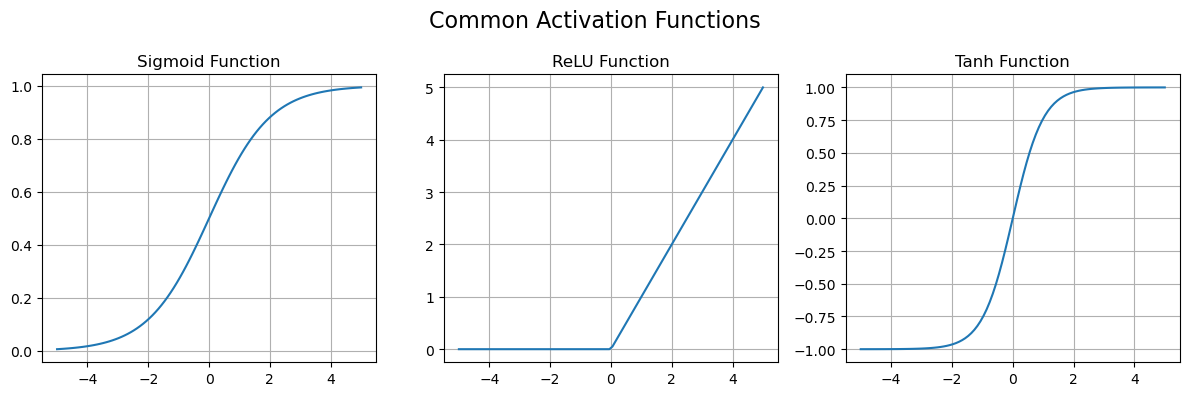

In [6]:
class ActivationFunctions:
    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    @staticmethod
    def relu(x):
        return np.maximum(0, x)
    
    @staticmethod
    def tanh(x):
        return np.tanh(x)

# Create input values
x = np.linspace(-5, 5, 100)

# Create subplots
fig, ((ax1, ax2,ax3)) = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Common Activation Functions', fontsize=16)

ax1.plot(x, ActivationFunctions.sigmoid(x))
ax1.set_title('Sigmoid Function')
ax1.grid(True)

ax2.plot(x, ActivationFunctions.relu(x))
ax2.set_title('ReLU Function')
ax2.grid(True)

ax3.plot(x, ActivationFunctions.tanh(x))
ax3.set_title('Tanh Function')
ax3.grid(True)

plt.tight_layout()
plt.show()


## 1.4 Hidden Layer
 The hidden layer, sitting between the input and output layers, is responsible for learning complex patterns in the data.
 
 Each neuron in the hidden layer applies a weighted sum of its inputs followed by a non-linear activation function.
 
 By stacking one or more hidden layers, neural networks can model intricate relationships and capture non-linearities that simple linear models cannot.
 
 The choice of the number of hidden layers and the number of neurons in each layer can significantly affect the network's ability to learn from data.


In [7]:
# Shallow network: Input -> Hidden -> Output (manual implementation)

def shallow_net_forward(x):
    # x shape: (input_size, batch_size)
    z1 = np.dot(W1, x) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    return z2  # Output (no activation for output layer here)

In [8]:
# Deep network: Input -> Hidden1 -> Hidden2 -> Hidden3 -> Output (manual implementation)

def deep_net_forward(x):
    # x shape: (input_size, batch_size)
    z1 = np.dot(W1, x) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)
    z3 = np.dot(W3, a2) + b3
    a3 = relu(z3)
    z4 = np.dot(W4, a3) + b4
    return z4  # Output (no activation for output layer here)

## 1.5 Output Layer

 The output layer is the final component of a neural network and is responsible for producing the network's predictions.
 Its structure and activation function depend on the specific task at hand:
 - For regression problems, the output layer typically consists of a single neuron with a linear activation.
 - For binary classification, it usually has one neuron with a sigmoid activation to output probabilities between 0 and 1.
 - For multi-class classification, the output layer contains one neuron per class and uses the softmax activation to generate a probability distribution over all possible classes.
 
 The design of the output layer is crucial, as it directly affects how the network's predictions are interpreted and how the loss is computed during training.


In [9]:
def forward(self, X):
    self.input = X
    self.z = np.dot(self.weights, X) + self.biases
    
    if self.task == 'regression':
        self.output = self.z  # Linear activation
    elif self.task == 'binary':
        self.output = 1 / (1 + np.exp(-self.z))  # Sigmoid
    else:  # multiclass
        exp_z = np.exp(self.z - np.max(self.z))
        self.output = exp_z / np.sum(exp_z, axis=0)
    return self.output

In [10]:
#Backpropagation - Implementation
def backward(self, y_true, learning_rate=0.01):
    m = y_true.shape[1]
    
    if self.task == 'regression':
        self.dz = (self.output - y_true) / m
    elif self.task == 'binary':
        self.dz = (self.output - y_true) / (m * self.output * (1 - self.output))
    else:  # multiclass
        self.dz = (self.output - y_true) / m
    
    # Compute gradients
    self.dW = np.dot(self.dz, self.input.T)
    self.db = np.sum(self.dz, axis=1, keepdims=True)
    
    # Update parameters
    self.weights -= learning_rate * self.dW
    self.biases -= learning_rate * self.db
    
    # Return gradient for previous layer
    return np.dot(self.weights.T, self.dz)

In [12]:
# we use the ingradients above to construct a neural network to do the regression.

import numpy as np
    # Define a neural network with 2 hidden layers (100, 50 neurons) for regression
class SimpleANN:
    def __init__(self, input_dim, output_dim=1):
        self.input_dim = input_dim
        self.output_dim = output_dim
        # Layer sizes
        self.h1 = 100
        self.h2 = 50
        # Initialize weights and biases
        self.W1 = np.random.randn(self.h1, input_dim) * 0.01
        self.b1 = np.zeros((self.h1, 1))
        self.W2 = np.random.randn(self.h2, self.h1) * 0.01
        self.b2 = np.zeros((self.h2, 1))
        self.W3 = np.random.randn(output_dim, self.h2) * 0.01
        self.b3 = np.zeros((output_dim, 1))
    
    def forward(self, X):
        self.X = X
        # First hidden layer
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = np.maximum(0, self.Z1)  # ReLU
        # Second hidden layer
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = np.maximum(0, self.Z2)  # ReLU
        # Output layer
        self.Z3 = np.dot(self.W3, self.A2) + self.b3
     
        self.output = self.Z3  # Linear activation
        
        return self.output

    def backward(self, y_true, learning_rate=0.01):
        m = y_true.shape[1]
        # Output layer gradient
        dZ3 = (self.output - y_true) / m
        dW3 = np.dot(dZ3, self.A2.T)
        db3 = np.sum(dZ3, axis=1, keepdims=True)
        # Backprop to second hidden layer
        dA2 = np.dot(self.W3.T, dZ3)
        dZ2 = dA2 * (self.Z2 > 0)
        dW2 = np.dot(dZ2, self.A1.T)
        db2 = np.sum(dZ2, axis=1, keepdims=True)
        # Backprop to first hidden layer
        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * (self.Z1 > 0)
        dW1 = np.dot(dZ1, self.X.T)
        db1 = np.sum(dZ1, axis=1, keepdims=True)
        # Update parameters
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        # Return gradient for previous layer (not used here)
        return

if __name__ == "__main__":
    from sklearn.datasets import fetch_california_housing
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split

    # Load dataset
    #housing = fetch_california_housing()
    #X, y = housing.data, housing.target
    #print(X.shape, y.shape)

    # Load the dataset from Excel
    df = pd.read_excel("/Teach/129_AI/Week10-11/fetch_california_housing.xlsx")

    # Rename target column to match common naming
    df = df.rename(columns={'target': 'Price'})

    X = df.drop(columns=['Price'])
    y = df['Price']

    # Basic statistics（
    print("Dataset Shape:", df.shape)
    print("\nFeature Statistics:")
    print(df.describe())
    
    # Standardize features
    X_scaled = StandardScaler().fit_transform(X)

    # Split data (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Ensure data is numpy arrays
    X_train_np = np.asarray(X_train)
    X_test_np = np.asarray(X_test)
    y_train_np = np.asarray(y_train)
    y_test_np = np.asarray(y_test)

    # Transpose data to shape (features, samples)
    X_train_T = X_train_np.T
    X_test_T = X_test_np.T
    y_train_T = y_train_np.reshape(1, -1)
    y_test_T = y_test_np.reshape(1, -1)

    # Instantiate the network
    ann = SimpleANN(input_dim=X_train_T.shape[0], output_dim=1)

    # Training loop
    epochs = 1000
    learning_rate = 0.01
    for epoch in range(epochs):
        # Forward pass
        y_pred = ann.forward(X_train_T)
        # Compute loss (MSE)
        loss = np.mean((y_pred - y_train_T) ** 2)
        # Backward pass
        ann.backward(y_train_T, learning_rate=learning_rate)
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

    # Evaluate on test set
    y_test_pred = ann.forward(X_test_T)
    test_loss = np.mean((y_test_pred - y_test_T) ** 2)
    print(f"Test MSE: {test_loss:.4f}")

    

Dataset Shape: (20640, 9)

Feature Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532  

## Auto Backpropagation
Actually, we donot need to write the backpropagation mannully. We can leverage the package Scikit-learn to implement the learning process. 

# 2. Neural Network Regression with Scikit-learn

After implementing our own neural network from scratch, let's see how to use scikit-learn's implementation for regression tasks. This provides a good comparison between custom implementation and industry-standard tools.

In [14]:
# Import additional required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
#housing = fetch_california_housing()
#X, y = housing.data, housing.target

# Load the dataset from Excel
df = pd.read_excel("/Teach/129_AI/Week10-11/fetch_california_housing.xlsx")

# Rename target column to match common naming
df = df.rename(columns={'target': 'Price'})

X = df.drop(columns=['Price'])
y = df['Price']

# Basic statistics（
print("Dataset Shape:", df.shape)
print("\nFeature Statistics:")
print(df.describe())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dataset shape:")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Training set: {y_train.shape}")
print(f"Testing set: {y_test.shape}")
print()
print("\nFeature names:", df.columns)
#print("\nFeature names:", housing.feature_names)


Dataset Shape: (20640, 9)

Feature Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532  

In [15]:
# Create and configure the Neural Network
model = MLPRegressor(
    hidden_layer_sizes=(100, 50),  # Two hidden layers with 100 and 50 neurons
    activation='relu',             # ReLU activation function
    solver='adam',                 # Adam optimizer
    max_iter=1000,                # Maximum number of iterations
    random_state=42,              # For reproducibility
    learning_rate_init=0.001      # Initial learning rate
)

# Train the model
print("Training the model...")
model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
print(y_train_pred.shape)
print(X_train_scaled.shape)
y_test_pred = model.predict(X_test_scaled)

# Calculate performance metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nModel Performance:")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")


Training the model...
(16512,)
(16512, 8)

Model Performance:
Training MSE: 0.2034
Testing MSE: 0.2710
Training R² Score: 0.8479
Testing R² Score: 0.7932


(16512,)
(16512, 8)
(16512,)


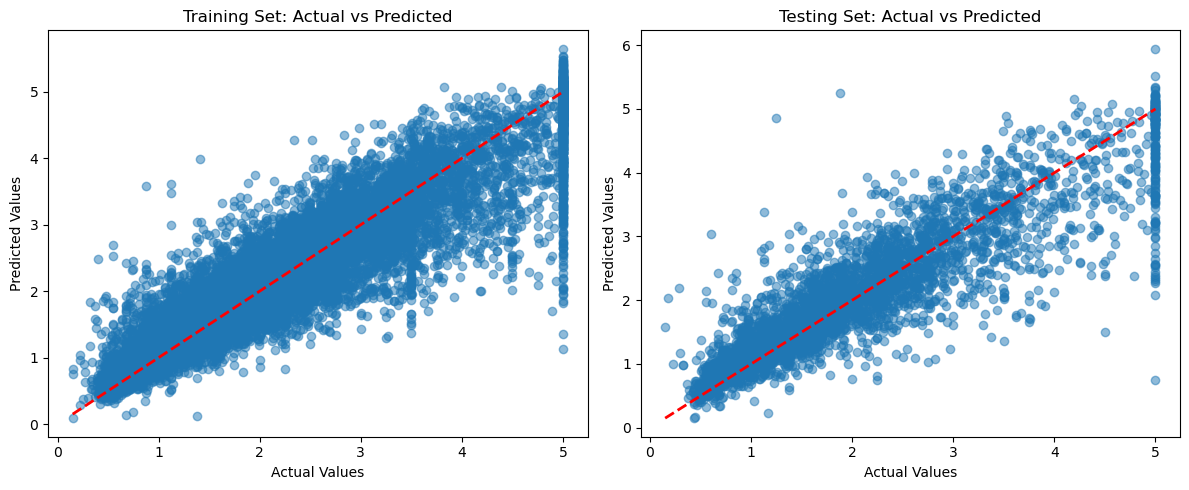

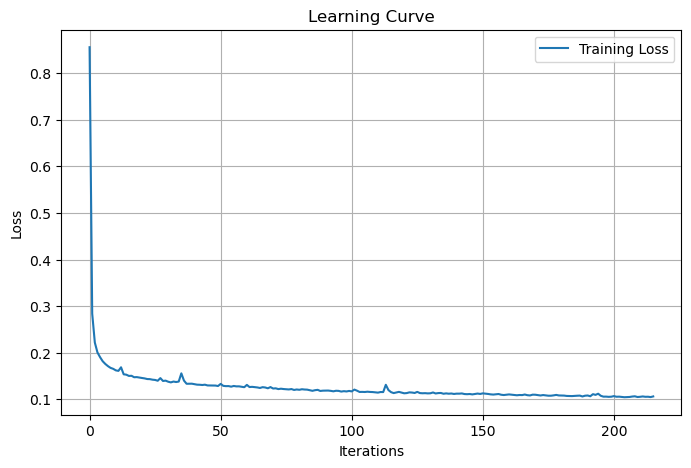

In [16]:
# Visualize actual vs predicted values
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
print(y_train.shape)
print(X_train.shape)
print(y_train_pred.shape)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Training Set: Actual vs Predicted')

# Testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Testing Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


# Understanding the Results

Let's break down what we did in this example:

1. **Data Preparation**:
   - We used the California Housing dataset, which contains housing prices and various features
   - The data was split into training (80%) and testing (20%) sets
   - Features were standardized using StandardScaler to help with model convergence

2. **Model Architecture**:
   - We used MLPRegressor (Multi-Layer Perceptron Regressor)
   - Two hidden layers with 100 and 50 neurons respectively
   - ReLU activation function for non-linearity
   - Adam optimizer for efficient training
   - Learning rate of 0.001

3. **Training and Evaluation**:
   - The model was trained for up to 1000 iterations
   - We evaluated performance using:
     - Mean Squared Error (MSE): measures average squared difference between predictions and actual values
     - R² Score: indicates the proportion of variance in the target that's predictable from the features

4. **Visualization**:
   - Actual vs Predicted plots show how well our predictions match the true values
   - Points closer to the diagonal line indicate better predictions
   - The learning curve shows how the loss decreased during training

This example demonstrates how neural networks can be effectively used for regression tasks. The model learns to predict continuous values (house prices) based on multiple input features.


# 3. Neural Network Classification Example using Scikit-learn

Now that we have built and improved our neural network, let's apply it to a binary classification problem. We'll:

1. Generate a more complex dataset
2. Preprocess the data
3. Train the network
4. Evaluate performance
5. Visualize decision boundaries


Train Loss: 0.1115, Train Accuracy: 0.9525
Test Loss: 0.1562, Test Accuracy: 0.9400


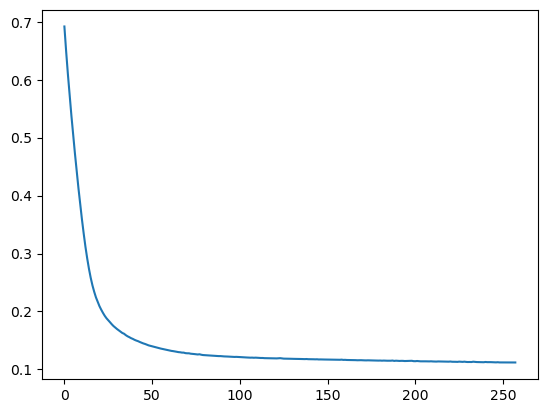

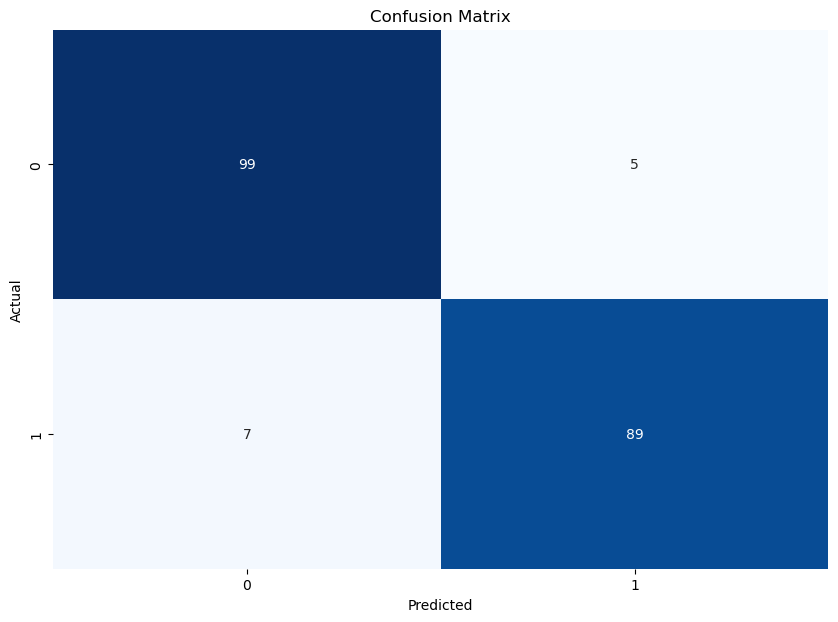

In [17]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if __name__ == "__main__":
    # Generate synthetic classification data
    X, y = make_classification(
        n_samples=1000, n_features=2, n_redundant=0,
        n_informative=2, random_state=42,
        n_clusters_per_class=1
    )
    y = y.reshape(-1, 1)

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # Flatten y for sklearn
    y_train = y_train.ravel()
    y_test = y_test.ravel()

    # Define and train a simple ANN classifier
    clf = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    clf.fit(X_train, y_train)

    # Predict and evaluate
    y_pred_proba = clf.predict_proba(X_train)[:, 1]
    train_loss = log_loss(y_train, y_pred_proba)
    y_pred = clf.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred)
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")

    y_test_pred_proba = clf.predict_proba(X_test)[:, 1]
    test_loss = log_loss(y_test, y_test_pred_proba)
    y_test_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    #plot the loss curve
    plt.plot(clf.loss_curve_)
    plt.show()

    #plot the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')




# 4. Conclusion and Further Improvements

We have successfully built a neural network from scratch and applied it to both simple (XOR) and complex (binary classification) problems. 

## References
1. Neural Networks and Deep Learning by Michael Nielsen
2. Deep Learning by Ian Goodfellow, Yoshua Bengio, and Aaron Courville
3. GeeksforGeeks ANN Tutorial

This implementation serves as a foundation for understanding neural networks. For production use, consider using established frameworks like TensorFlow or PyTorch.
